In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)
print("环境配置成功！")

Pandas version: 3.0.6
环境配置成功！


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/all_airports.csv')

print(f"数据总规模: {df.shape}")
print("\n各列的数据类型:")
print(df.dtypes)

数据总规模: (11723420, 13)

各列的数据类型:
id                    float64
flight_date               str
dep_airport               str
arr_airport               str
status                    str
scheduled_dep_time    float64
scheduled_arr_date        str
scheduled_arr_time        str
actual_dep_date           str
actual_dep_time           str
actual_arr_date           str
actual_arr_time           str
other                     str
dtype: object


In [ ]:
missing = df.isnull().sum()
print("各字段缺失值数量:")
print(missing[missing > 0])

各字段缺失值数量:
id                    11723420
status                       2
scheduled_dep_time    11723420
scheduled_arr_date         679
scheduled_arr_time          17
actual_dep_date           6901
actual_dep_time         453753
actual_arr_date         502920
actual_arr_time         574544
other                   600159
dtype: int64


In [ ]:
df = df.drop(columns=['id', 'scheduled_dep_time'])

df = df.rename(columns={
    'scheduled_arr_date': 'scheduled_dep_time',   # 15:30
    'scheduled_arr_time': 'scheduled_arr_date',   # 2015-01-01
    'actual_dep_date': 'scheduled_arr_time',      # 18:35
    'actual_dep_time': 'actual_dep_date',         # 2015-01-01
    'actual_arr_date': 'actual_dep_time',         # 15:53
    'actual_arr_time': 'actual_arr_date',         # 2015-01-01
    'other': 'actual_arr_time'                     # 18:23
})

print("列名修复完成！现在看看前5行数据：")
print(df[['flight_date', 'dep_airport', 'arr_airport', 'status', 'scheduled_dep_time', 'scheduled_arr_time', 'actual_dep_time', 'actual_arr_time']].head())

列名修复完成！现在看看前5行数据：
  flight_date dep_airport arr_airport status scheduled_dep_time  \
0  2015-01-01         WXN         CAN     开舱              15:35   
1  2015-01-01         FOC         CAN     取消              21:50   
2  2015-01-01         CAN         CDG     开舱              00:20   
3  2015-01-01         CAN         NKG     到达              10:45   
4  2015-01-01         CAN         NRT     到达              15:15   

  scheduled_arr_time actual_dep_time actual_arr_time  
0              17:40           15:25           16:59  
1              23:25             NaN             NaN  
2              13:40           00:53           13:36  
3              12:55           11:23           13:09  
4              19:10           15:32           18:54  


In [ ]:
df['scheduled_dep_datetime'] = pd.to_datetime(
    df['flight_date'] + ' ' + df['scheduled_dep_time'], 
    errors='coerce'
)

df['actual_dep_datetime'] = pd.to_datetime(
    df['actual_dep_date'] + ' ' + df['actual_dep_time'].fillna('00:00'), 
    errors='coerce'
)

df['departure_delay_min'] = (
    df['actual_dep_datetime'] - df['scheduled_dep_datetime']
).dt.total_seconds() / 60

df_valid = df[df['departure_delay_min'].notna()].copy()

print(f"原始总航班数: {len(df):,}")
print(f"有效航班数（有实际起飞时间）: {len(df_valid):,}")
print("\n延误时长统计描述:")
print(df_valid['departure_delay_min'].describe())

原始总航班数: 11,723,420
有效航班数（有实际起飞时间）: 11,269,654

延误时长统计描述:
count    1.126965e+07
mean     3.482379e+01
std      8.902973e+01
min     -2.895000e+03
25%      1.000000e+01
50%      1.900000e+01
75%      3.900000e+01
max      2.640000e+03
Name: departure_delay_min, dtype: float64


In [ ]:
def delay_level(minutes):
    if pd.isna(minutes):
        return '取消/未知'
    if minutes <= 15:
        return '准点'
    elif minutes <= 30:
        return '轻度延误'
    elif minutes <= 60:
        return '中度延误'
    else:
        return '重度延误'

df_valid['delay_level'] = df_valid['departure_delay_min'].apply(delay_level)

print("各延误等级的航班数分布：")
print(df_valid['delay_level'].value_counts())

各延误等级的航班数分布：
delay_level
准点      4610820
轻度延误    3016764
中度延误    1855707
重度延误    1786363
Name: count, dtype: int64


In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
df_valid.to_csv('../data/processed/all_airports_clean.csv', index=False)
print("清洗后的数据已保存至 data/processed/all_airports_clean.csv")

清洗后的数据已保存至 data/processed/all_airports_clean.csv


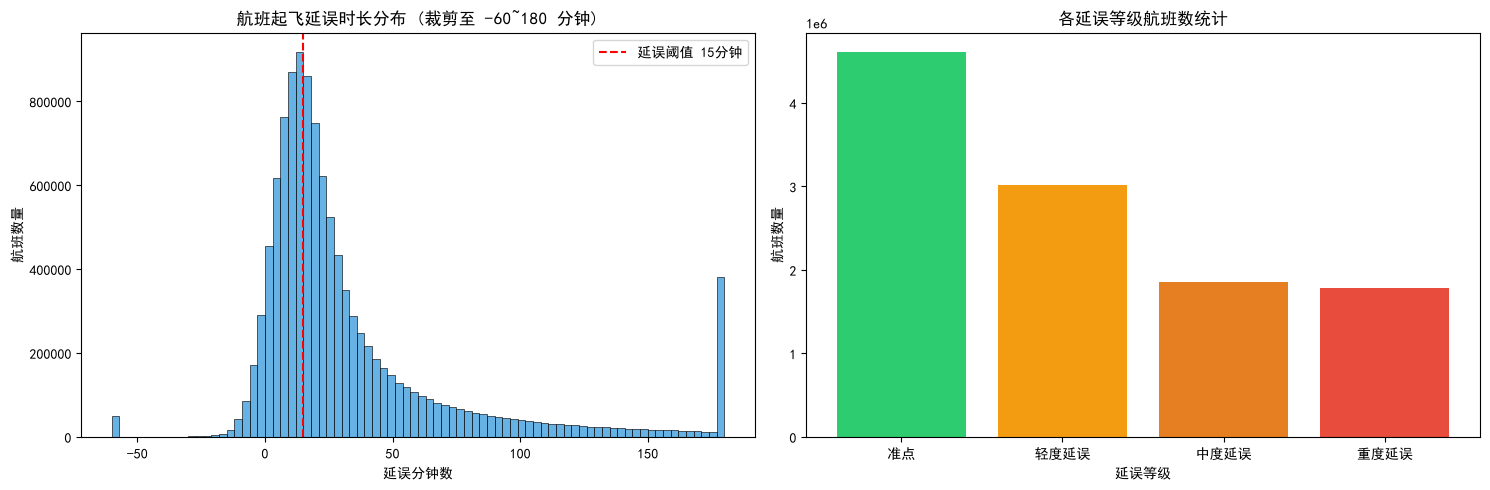

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_valid['departure_delay_min'].clip(-60, 180), bins=80, ax=axes[0], color='#3498db')
axes[0].axvline(15, color='red', linestyle='--', label='延误阈值 15分钟')
axes[0].set_title('航班起飞延误时长分布 (裁剪至 -60~180 分钟)')
axes[0].set_xlabel('延误分钟数')
axes[0].set_ylabel('航班数量')
axes[0].legend()

level_order = ['准点', '轻度延误', '中度延误', '重度延误']
counts = df_valid['delay_level'].value_counts().reindex(level_order)
axes[1].bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[1].set_title('各延误等级航班数统计')
axes[1].set_xlabel('延误等级')
axes[1].set_ylabel('航班数量')

plt.tight_layout()
plt.savefig('../data/processed/delay_distribution.png', dpi=150)
plt.show()

In [ ]:
df_valid['hour'] = df_valid['scheduled_dep_datetime'].dt.hour
df_valid['weekday'] = df_valid['scheduled_dep_datetime'].dt.dayofweek  # 0=周一, 6=周日
df_valid['month'] = df_valid['scheduled_dep_datetime'].dt.month

print("时间特征提取完成！")
print(df_valid[['scheduled_dep_datetime', 'hour', 'weekday', 'month']].head())

时间特征提取完成！
  scheduled_dep_datetime  hour  weekday  month
0    2015-01-01 15:35:00    15        3      1
2    2015-01-01 00:20:00     0        3      1
3    2015-01-01 10:45:00    10        3      1
4    2015-01-01 15:15:00    15        3      1
5    2015-01-01 06:50:00     6        3      1


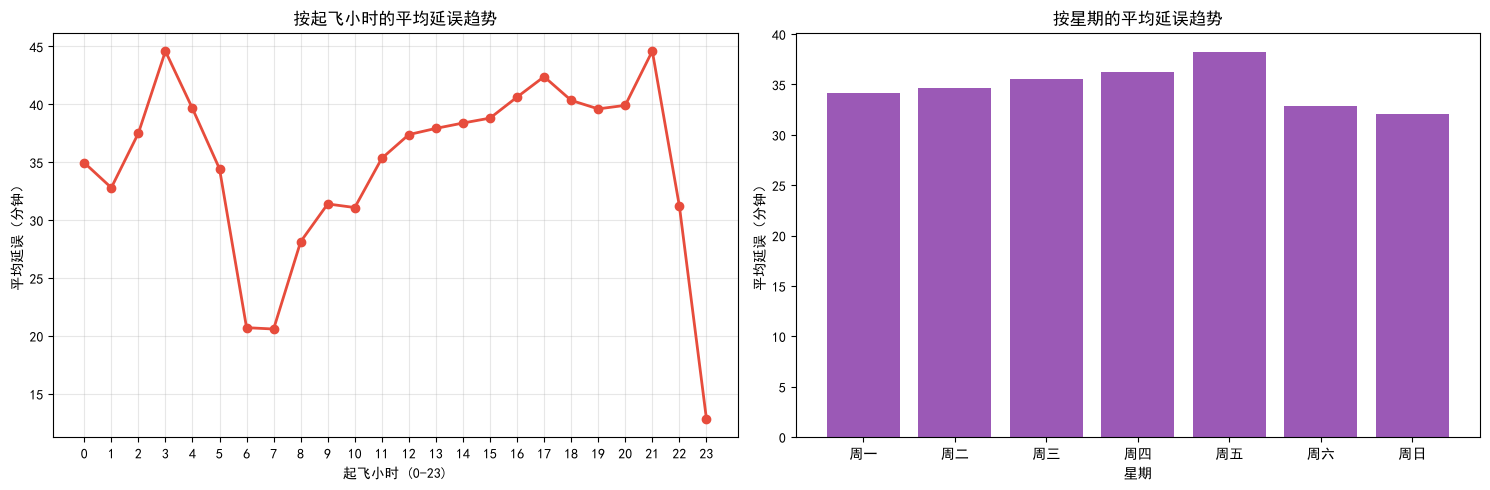

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly_delay = df_valid.groupby('hour')['departure_delay_min'].mean()
axes[0].plot(hourly_delay.index, hourly_delay.values, marker='o', color='#e74c3c', linewidth=2)
axes[0].set_title('按起飞小时的平均延误趋势')
axes[0].set_xlabel('起飞小时 (0-23)')
axes[0].set_ylabel('平均延误（分钟）')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24))

weekday_labels = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
weekday_delay = df_valid.groupby('weekday')['departure_delay_min'].mean()
axes[1].bar(weekday_labels, weekday_delay.values, color='#9b59b6')
axes[1].set_title('按星期的平均延误趋势')
axes[1].set_xlabel('星期')
axes[1].set_ylabel('平均延误（分钟）')

plt.tight_layout()
plt.savefig('../data/processed/temporal_patterns.png', dpi=150)
plt.show()

In [ ]:
hourly_count = df_valid.groupby('hour').size()
print("各起飞小时的航班数量：")
print(hourly_count)

各起飞小时的航班数量：
hour
0     108478
1     103437
2      81480
3      69031
4      62472
5      73997
6     402671
7     817701
8     813235
9     650949
10    593196
11    671128
12    672405
13    639785
14    584106
15    612223
16    691954
17    653650
18    586277
19    641071
20    621498
21    542979
22    360957
23    214974
dtype: int64
